<a href="https://colab.research.google.com/github/DKavya8/chestxray-bias-audit/blob/main/notebooks/RACK_Results_Figures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/team-RACK-bias-paper'
REPO_RAW = 'https://raw.githubusercontent.com/DKavya8/chestxray-bias-audit/main'

Mounted at /content/drive


In [2]:
import os, glob, json, urllib.request, urllib.parse, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert os.path.isdir(BASE), f'Folder not found: {BASE}'
OUT = os.path.join(BASE, 'figs', 'results')
os.makedirs(OUT, exist_ok=True)

DARK, ROSE, MID, PINK, BERRY = '#8f0707', '#be6c65', '#d7c2c1', '#de99a1', '#de6e8c'
INK = '#333333'
C_RAW, C_MATCH, C_IPW = ROSE, PINK, DARK
C_STD, C_ASBDC = MID, DARK

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10, 'axes.titlesize': 11,
    'axes.labelcolor': INK, 'xtick.color': INK, 'ytick.color': INK,
    'axes.edgecolor': INK, 'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 110, 'savefig.bbox': 'tight',
})

SOURCES = {}
def save(fig, name, sources):
    for ext in ('png', 'svg'):
        fig.savefig(os.path.join(OUT, f'{name}.{ext}'), dpi=300)
    SOURCES[name] = sources
    print('saved', name)

SPLIT_ORDER = [3658676649, 768519171, 113462462, 2748406118, 1569714665,
               2006902500, 342858866, 1591287646, 2763601433, 1524358342]
SPLIT_LABEL = {s: f'Split {i+1}' for i, s in enumerate(SPLIT_ORDER)}
FINDINGS = ['Atelectasis', 'Consolidation', 'Infiltration', 'Pneumothorax', 'Edema', 'Emphysema', 'Fibrosis',
            'Effusion', 'Pneumonia', 'Pleural_Thickening', 'Cardiomegaly', 'Nodule', 'Mass', 'Hernia']

In [18]:
def find(name, root=BASE, required=True):
    hits = glob.glob(os.path.join(root, '**', name), recursive=True)
    if len(hits) == 1:
        return hits[0]
    if not required and not hits:
        return None
    raise FileNotFoundError(f'{name}: expected 1 file under {root}, found {len(hits)}: {hits}')

def repo_file(rel):
    """Download a file from the team GitHub repo and return the local path."""
    local = os.path.join('/content/repo_files', os.path.basename(rel))
    os.makedirs('/content/repo_files', exist_ok=True)
    urllib.request.urlretrieve(f"{REPO_RAW}/{urllib.parse.quote(rel)}", local)
    return local

SRC = {
    'agestd':   find('group_b_densenet_agestd_with_ci.csv'),
    'patients': repo_file('results/group_b_densenet/group_b_patient_level (1).parquet'),
    'counts':   repo_file('results/group_b_densenet/group_b_counts_by_finding (1).parquet'),
    'negctl':   find('group_b_negative_control_points.csv', required=False),
    'c34':      find('conditions_3_4_by_split.csv'),
    'paired':   find('asbdc_vs_stdcal_paired_test.csv'),
    'op':       find('dS_by_operating_point.csv'),
    'bins':     repo_file('results/age_bin_robustness_by_split.csv'),
}
for k, v in SRC.items():
    print(f'{k:9s} {v}')
if SRC['negctl'] is None:
    print('\nNegative control file not found in your Drive. Figure 4 will be skipped until it is added.')

agestd    /content/drive/MyDrive/team-RACK-bias-paper/results/group_b_densenet/group_b_densenet_agestd_with_ci.csv
patients  /content/repo_files/group_b_patient_level (1).parquet
counts    /content/repo_files/group_b_counts_by_finding (1).parquet
negctl    /content/drive/MyDrive/team-RACK-bias-paper/results/group_b_negative_control_points.csv
c34       /content/drive/MyDrive/team-RACK-bias-paper/results/four_condition_grid/conditions_3_4_by_split.csv
paired    /content/drive/MyDrive/team-RACK-bias-paper/results/four_condition_grid/asbdc_vs_stdcal_paired_test.csv
op        /content/drive/MyDrive/team-RACK-bias-paper/results/operating_point_robustness/dS_by_operating_point.csv
bins      /content/repo_files/age_bin_robustness_by_split.csv


In [4]:
ag = pd.read_csv(SRC['agestd'])
ag['split_seed'] = ag['split_seed'].astype('int64')
ag = ag[ag['finding'] == 'NIH_14_pooled']
gap_rows = ag['subgroup'].str.startswith('sex_gap')
ag['method'] = ag['condition'].map({'condition_2_agestd_match': 'match', 'condition_3_agestd_ipw': 'ipw'})
assert ag['method'].notna().all(), f"Unexpected condition labels: {ag['condition'].unique()}"

gap = ag[gap_rows & (ag['metric'] == 'fnr')].pivot(index='split_seed', columns='method',
                                                     values=['value', 'ci_lower', 'ci_upper'])
red = ag[gap_rows & (ag['metric'] == 'fnr_gap_reduction')].pivot(index='split_seed', columns='method',
                                                                   values=['value', 'ci_lower', 'ci_upper'])
raw_from_match = gap[('value', 'match')] + red[('value', 'match')]
raw_from_ipw = gap[('value', 'ipw')] + red[('value', 'ipw')]
assert np.allclose(raw_from_match, raw_from_ipw, atol=1e-9), 'Raw gap differs between matching and IPW rows'

pooled = pd.DataFrame({
    'G_raw': raw_from_match, 'G_match': gap[('value', 'match')], 'G_ipw': gap[('value', 'ipw')],
    'D_match': red[('value', 'match')], 'D_match_lo': red[('ci_lower', 'match')], 'D_match_hi': red[('ci_upper', 'match')],
    'D_ipw': red[('value', 'ipw')], 'D_ipw_lo': red[('ci_lower', 'ipw')], 'D_ipw_hi': red[('ci_upper', 'ipw')],
}).reindex(SPLIT_ORDER)
assert pooled.notna().all().all(), 'Missing split in pooled data'
print(pooled[['G_raw', 'G_match', 'G_ipw', 'D_match', 'D_ipw']].mean().round(4))   # paper: 0.027, 0.016, 0.016, 0.011, 0.011

G_raw      0.0271
G_match    0.0161
G_ipw      0.0163
D_match    0.0110
D_ipw      0.0108
dtype: float64


saved fig1_gap_raw_vs_agestd_by_split


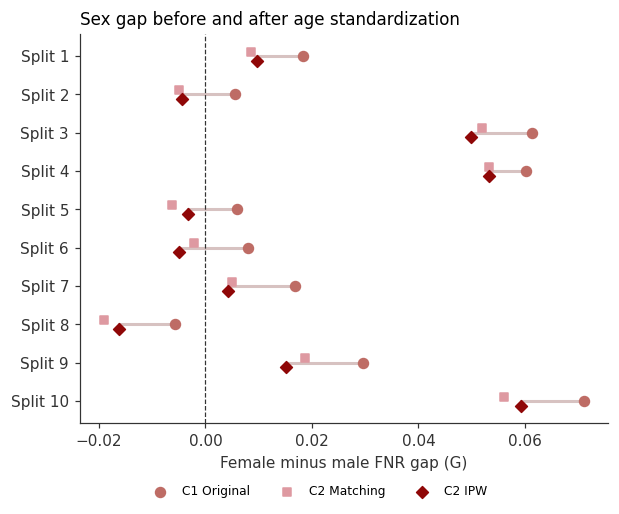

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 4.6))
y = np.arange(len(SPLIT_ORDER))[::-1]
for yi, (_, r) in zip(y, pooled.iterrows()):
    ax.plot([r.G_raw, r.G_ipw], [yi, yi], color=MID, lw=2, zorder=1)
ax.scatter(pooled.G_raw, y, color=C_RAW, s=42, zorder=3, label='C1 Original')
ax.scatter(pooled.G_match, y + 0.12, color=C_MATCH, s=30, marker='s', zorder=3, label='C2 Matching')
ax.scatter(pooled.G_ipw, y - 0.12, color=C_IPW, s=30, marker='D', zorder=3, label='C2 IPW')
ax.axvline(0, color=INK, lw=0.8, ls='--')
ax.set_yticks(y); ax.set_yticklabels([SPLIT_LABEL[s] for s in SPLIT_ORDER])
ax.set_xlabel('Female minus male FNR gap (G)')
ax.set_title('Sex gap before and after age standardization', loc='left')
ax.legend(frameon=False, fontsize=8, loc='upper center', bbox_to_anchor=(0.45, -0.13), ncol=3)
save(fig, 'fig1_gap_raw_vs_agestd_by_split', ['agestd']); plt.show()

saved fig2_gap_reduction_by_split


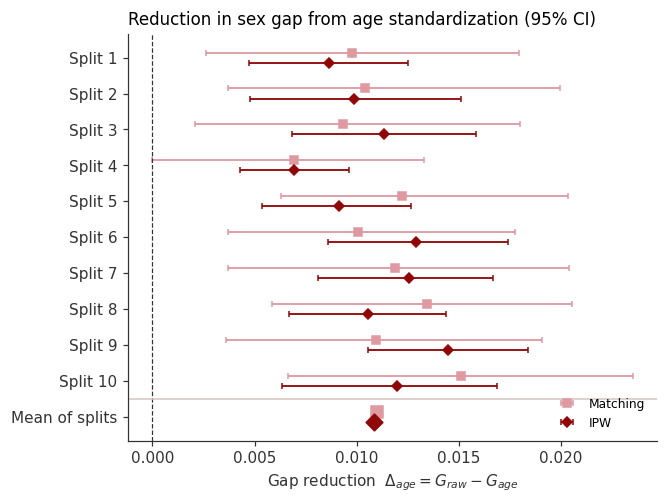

In [6]:
fig, ax = plt.subplots(figsize=(6.2, 4.8))
labels = [SPLIT_LABEL[s] for s in SPLIT_ORDER] + ['Mean of splits']
y = np.arange(len(labels))[::-1]
for col, lo, hi, color, marker, off, name in [('D_match', 'D_match_lo', 'D_match_hi', C_MATCH, 's', 0.14, 'Matching'),
                                              ('D_ipw', 'D_ipw_lo', 'D_ipw_hi', C_IPW, 'D', -0.14, 'IPW')]:
    v, l, h = pooled[col].values, pooled[lo].values, pooled[hi].values
    ax.errorbar(v, y[:-1] + off, xerr=[v - l, h - v], fmt=marker, color=color, ms=5, capsize=2, lw=1.2, label=name)
    ax.scatter(pooled[col].mean(), y[-1] + off, color=color, marker=marker, s=60, zorder=3)
ax.axvline(0, color=INK, lw=0.8, ls='--')
ax.axhline(y[-1] + 0.5, color=MID, lw=1)
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_xlabel(r'Gap reduction  $\Delta_{age} = G_{raw} - G_{age}$')
ax.set_title('Reduction in sex gap from age standardization (95% CI)', loc='left')
ax.legend(frameon=False, fontsize=8, loc='lower right')
save(fig, 'fig2_gap_reduction_by_split', ['agestd']); plt.show()

In [7]:
pl = pd.read_parquet(SRC['patients'])
cnt = pd.read_parquet(SRC['counts'])
thr = (cnt[cnt.condition == 'raw'][['split_seed', 'finding', 'threshold']]
       .drop_duplicates().set_index(['split_seed', 'finding'])['threshold'])
splits = sorted(pl.split_seed.unique())

def fnr_weighted(is_fn, w):
    tot = w.sum()
    return (w[is_fn].sum() / tot) if tot > 0 else np.nan

def per_split_stats(d, seed, idx=None):
    dd = d if idx is None else d.iloc[idx]
    sex = dd['sex'].values
    out = {}
    for f in FINDINGS:
        t = thr.loc[(seed, f)]
        yv = dd['y_' + f].values; pred = (dd['s_' + f].values >= t).astype(int)
        fn = (yv == 1) & (pred == 0); pos = (yv == 1)
        g = {}
        for cond, wcol in [('raw', None), ('match', 'matched_frac'), ('ipw', 'ipw_weight')]:
            w = np.ones(len(dd)) if wcol is None else dd[wcol].values
            g[cond] = (fnr_weighted(fn[pos & (sex == 'F')], w[pos & (sex == 'F')])
                       - fnr_weighted(fn[pos & (sex == 'M')], w[pos & (sex == 'M')]))
        out[f] = (g['raw'], g['match'], g['ipw'], g['raw'] - g['match'], g['raw'] - g['ipw'])
    return out

cache = {s: pl[pl.split_seed == s].reset_index(drop=True) for s in splits}
point = {f: np.zeros(5) for f in FINDINGS}
for s in splits:
    st = per_split_stats(cache[s], s)
    for f in FINDINGS: point[f] += np.array(st[f]) / len(splits)

B = 1000
rng = np.random.default_rng(20260823)
pmap = {s: cache[s].groupby('Patient ID').indices for s in splits}
draws = {f: np.full((B, 5), np.nan) for f in FINDINGS}
t0 = time.time()
for b in range(B):
    if b % 200 == 0: print(f'draw {b}/{B}  ({time.time() - t0:.0f}s)')
    acc = {f: np.zeros(5) for f in FINDINGS}
    for s in splits:
        pids = np.array(list(pmap[s].keys()))
        samp = rng.choice(pids, size=len(pids), replace=True)
        idx = np.concatenate([pmap[s][p] for p in samp])
        st = per_split_stats(cache[s], s, idx)
        for f in FINDINGS: acc[f] += np.array(st[f]) / len(splits)
    for f in FINDINGS: draws[f][b] = acc[f]

def bh_significant(k):
    p = np.array([min(1.0, 2 * min(np.mean(draws[f][:, k] <= 0), 1 - np.mean(draws[f][:, k] <= 0))) for f in FINDINGS])
    order_ = np.argsort(p); m = len(p)
    passed = p[order_] <= (np.arange(1, m + 1) / m) * 0.05
    kmax = np.where(passed)[0].max() + 1 if passed.any() else 0
    sig = np.zeros(m, bool); sig[order_[:kmax]] = True
    return dict(zip(FINDINGS, sig)), dict(zip(FINDINGS, p))

sig_ipw, p_ipw = bh_significant(4)
sig_match, p_match = bh_significant(3)
positives = {f: int(pl['y_' + f].sum()) for f in FINDINGS}
fin = pd.DataFrame([{
    'finding': f, 'pooled_positives': positives[f],
    'dS_match': point[f][3], 'dS_match_lo': np.nanpercentile(draws[f][:, 3], 2.5), 'dS_match_hi': np.nanpercentile(draws[f][:, 3], 97.5),
    'dS_match_p': p_match[f], 'dS_match_bh_sig': sig_match[f],
    'dS_ipw': point[f][4], 'dS_ipw_lo': np.nanpercentile(draws[f][:, 4], 2.5), 'dS_ipw_hi': np.nanpercentile(draws[f][:, 4], 97.5),
    'dS_ipw_p': p_ipw[f], 'dS_ipw_bh_sig': sig_ipw[f],
} for f in FINDINGS])
fin.to_csv(os.path.join(OUT, 'group_b_disease_level_with_ci.csv'), index=False)
print(f"BH significant: IPW {fin.dS_ipw_bh_sig.sum()}/14, matching {fin.dS_match_bh_sig.sum()}/14")   # paper: 11/14 and 9/14
print(fin.set_index('finding')[['dS_ipw', 'dS_match', 'pooled_positives']].round(4).sort_values('dS_ipw', ascending=False))

draw 0/1000  (0s)
draw 200/1000  (95s)
draw 400/1000  (186s)
draw 600/1000  (274s)
draw 800/1000  (362s)
BH significant: IPW 11/14, matching 9/14
                    dS_ipw  dS_match  pooled_positives
finding                                               
Hernia              0.0214    0.0398               157
Fibrosis            0.0201    0.0235              1138
Emphysema           0.0196    0.0142               538
Consolidation       0.0139    0.0162               838
Pneumothorax        0.0129    0.0050               535
Pleural_Thickening  0.0107    0.0128              1546
Atelectasis         0.0099    0.0088              3351
Pneumonia           0.0079    0.0064               372
Infiltration        0.0078    0.0091              7251
Effusion            0.0070    0.0097              2560
Cardiomegaly        0.0058    0.0081              1560
Mass                0.0037    0.0035              2553
Nodule              0.0017   -0.0013              3287
Edema              -0.0142   

saved fig3_per_finding_reduction


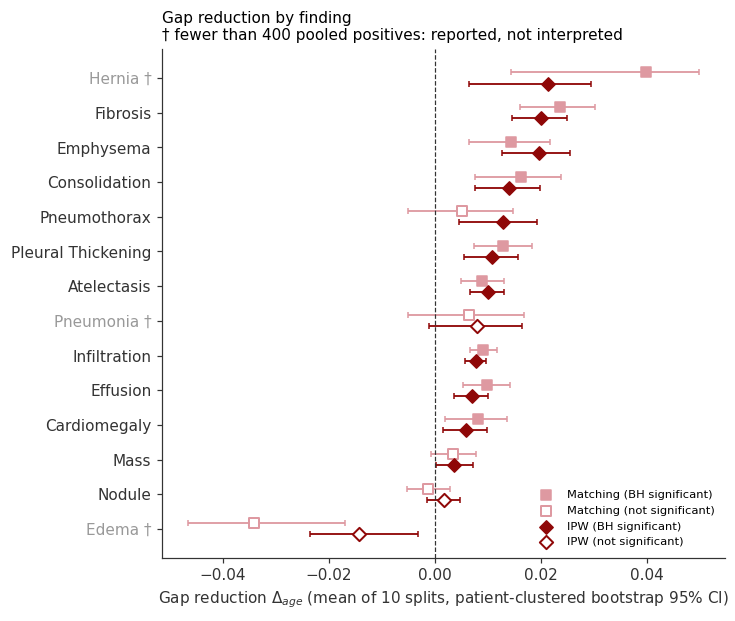

In [8]:
fs = fin.sort_values('dS_ipw').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(6.6, 6.0))
yy = np.arange(len(fs))
for col, color, marker, off, name, sigcol in [('dS_match', C_MATCH, 's', 0.16, 'Matching', 'dS_match_bh_sig'),
                                             ('dS_ipw', C_IPW, 'D', -0.16, 'IPW', 'dS_ipw_bh_sig')]:
    v, lo, hi = fs[col], fs[col + '_lo'], fs[col + '_hi']
    ax.errorbar(v, yy + off, xerr=[v - lo, hi - v], fmt='none', ecolor=color, lw=1.2, capsize=2)
    sig = fs[sigcol].values
    ax.scatter(v[sig], (yy + off)[sig], color=color, marker=marker, s=38, zorder=3, label=f'{name} (BH significant)')
    ax.scatter(v[~sig], (yy + off)[~sig], facecolor='white', edgecolor=color, marker=marker, s=38, lw=1.3, zorder=3,
               label=f'{name} (not significant)')
ax.axvline(0, color=INK, lw=0.8, ls='--')
rare = fs['pooled_positives'] < 400
ax.set_yticks(yy)
ax.set_yticklabels([f.replace('_', ' ') + (' †' if r else '') for f, r in zip(fs['finding'], rare)])
for lab, r in zip(ax.get_yticklabels(), rare):
    if r: lab.set_color('#999999')
ax.set_xlabel(r'Gap reduction $\Delta_{age}$ (mean of 10 splits, patient-clustered bootstrap 95% CI)')
ax.set_title('Gap reduction by finding\n† fewer than 400 pooled positives: reported, not interpreted', loc='left', fontsize=10)
ax.legend(frameon=False, fontsize=7.5, loc='lower right')
save(fig, 'fig3_per_finding_reduction', ['patients', 'counts']); plt.show()

saved fig4_negative_control


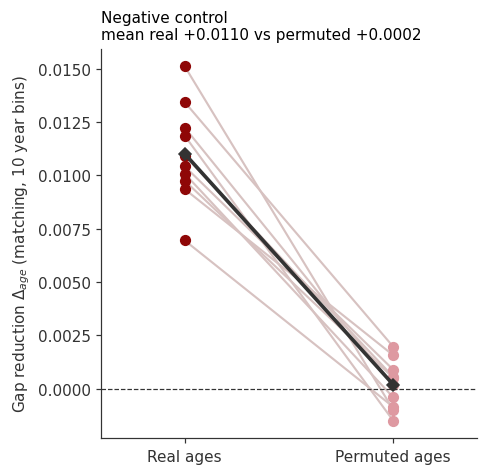

In [19]:
if SRC['negctl'] is not None:
    nc = pd.read_csv(SRC['negctl']).astype({'split_seed': 'int64'}).set_index('split_seed').reindex(SPLIT_ORDER)
    fig, ax = plt.subplots(figsize=(4.4, 4.6))
    for s in SPLIT_ORDER:
        ax.plot([0, 1], [nc.loc[s, 'dS_real'], nc.loc[s, 'dS_fake10']], color=MID, lw=1.4, zorder=1)
    ax.scatter(np.zeros(len(nc)), nc['dS_real'], color=DARK, s=40, zorder=2)
    ax.scatter(np.ones(len(nc)), nc['dS_fake10'], color=PINK, s=40, zorder=2)
    ax.plot([0, 1], [nc['dS_real'].mean(), nc['dS_fake10'].mean()], color=INK, lw=2.4, marker='D', ms=6, zorder=3)
    ax.axhline(0, color=INK, lw=0.8, ls='--')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Real ages', 'Permuted ages'])
    ax.set_xlim(-0.4, 1.4)
    ax.set_ylabel(r'Gap reduction $\Delta_{age}$ (matching, 10 year bins)')
    ax.set_title(f"Negative control\nmean real {nc['dS_real'].mean():+.4f} vs permuted {nc['dS_fake10'].mean():+.4f}",
                 loc='left', fontsize=10)
    save(fig, 'fig4_negative_control', ['negctl']); plt.show()
else:
    print('Skipped Figure 4: group_b_negative_control_points.csv is not in your Drive yet.')

saved fig5_asbdc_vs_standard_calibration


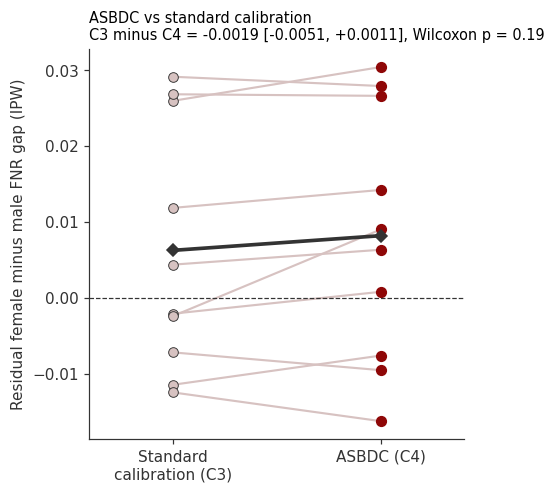

In [10]:
c34 = pd.read_csv(SRC['c34']).astype({'seed': 'int64'}).set_index('seed').reindex(SPLIT_ORDER)
pt = pd.read_csv(SRC['paired']).iloc[0]
assert abs((c34['c3_ipw'] - c34['c4_ipw']).mean() - pt['mean_diff']) < 1e-4, 'Paired test file and grid disagree'

fig, ax = plt.subplots(figsize=(4.4, 4.6))
for s in SPLIT_ORDER:
    ax.plot([0, 1], [c34.loc[s, 'c3_ipw'], c34.loc[s, 'c4_ipw']], color=MID, lw=1.4, zorder=1)
ax.scatter(np.zeros(len(c34)), c34['c3_ipw'], color=C_STD, edgecolor=INK, lw=0.6, s=40, zorder=2)
ax.scatter(np.ones(len(c34)), c34['c4_ipw'], color=C_ASBDC, s=40, zorder=2)
ax.plot([0, 1], [c34['c3_ipw'].mean(), c34['c4_ipw'].mean()], color=INK, lw=2.4, marker='D', ms=6, zorder=3)
ax.axhline(0, color=INK, lw=0.8, ls='--')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Standard\ncalibration (C3)', 'ASBDC (C4)'])
ax.set_xlim(-0.4, 1.4)
ax.set_ylabel('Residual female minus male FNR gap (IPW)')
ax.set_title(f"ASBDC vs standard calibration\nC3 minus C4 = {pt['mean_diff']:+.4f} "
             f"[{pt['ci_lower']:+.4f}, {pt['ci_upper']:+.4f}], Wilcoxon p = {pt['wilcoxon_p']:.2f}",
             loc='left', fontsize=9.5)
save(fig, 'fig5_asbdc_vs_standard_calibration', ['c34', 'paired']); plt.show()

saved fig6_operating_point_robustness


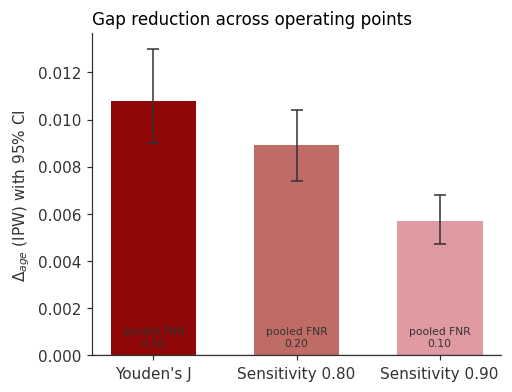

In [16]:
op = pd.read_csv(SRC['op'])
names = {'youden_current': "Youden's J", 'sensitivity_0.80': 'Sensitivity 0.80', 'sensitivity_0.90': 'Sensitivity 0.90'}
op['label'] = op['operating_point'].map(names).fillna(op['operating_point'])
fig, ax = plt.subplots(figsize=(4.8, 3.8))
x = np.arange(len(op))
ax.bar(x, op['dS_ipw'], color=[DARK, ROSE, PINK][:len(op)], width=0.6,
       yerr=[op['dS_ipw'] - op['ci_lower'], op['ci_upper'] - op['dS_ipw']],
       error_kw=dict(ecolor=INK, lw=1, capsize=4))
for xi, f in zip(x, op['pooled_fnr']):
    ax.text(xi, 0.0003, f'pooled FNR\n{f:.2f}', ha='center', va='bottom', fontsize=7, color=INK)
ax.axhline(0, color=INK, lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(op['label'])
ax.set_ylabel(r'$\Delta_{age}$ (IPW) with 95% CI')
ax.set_title('Gap reduction across operating points', loc='left')
save(fig, 'fig6_operating_point_robustness', ['op']); plt.show()

saved fig7_age_bin_sensitivity


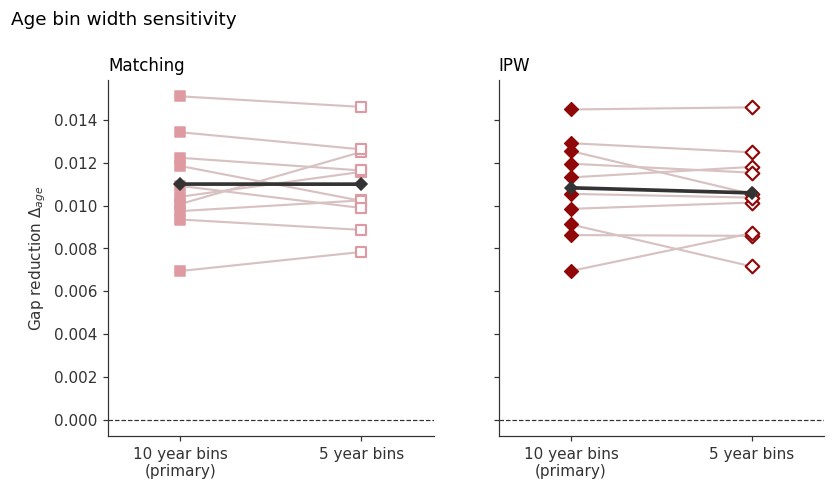

In [12]:
bins = pd.read_csv(SRC['bins']).astype({'split_seed': 'int64'})
fig, axes = plt.subplots(1, 2, figsize=(8.4, 4.2), sharey=True)
for ax, col, color, marker, title in [(axes[0], 'dS_match', C_MATCH, 's', 'Matching'), (axes[1], 'dS_ipw', C_IPW, 'D', 'IPW')]:
    wide = bins.pivot(index='split_seed', columns='bin_width', values=col).reindex(SPLIT_ORDER)
    for s in SPLIT_ORDER:
        ax.plot([0, 1], [wide.loc[s, 10], wide.loc[s, 5]], color=MID, lw=1.4, zorder=1)
    ax.scatter(np.zeros(len(wide)), wide[10], color=color, marker=marker, s=40, zorder=2)
    ax.scatter(np.ones(len(wide)), wide[5], edgecolor=color, facecolor='white', marker=marker, s=40, lw=1.4, zorder=2)
    ax.plot([0, 1], [wide[10].mean(), wide[5].mean()], color=INK, lw=2.4, marker='D', ms=6, zorder=3)
    ax.axhline(0, color=INK, lw=0.8, ls='--')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['10 year bins\n(primary)', '5 year bins'])
    ax.set_xlim(-0.4, 1.4); ax.set_title(title, loc='left')
axes[0].set_ylabel(r'Gap reduction $\Delta_{age}$')
fig.suptitle('Age bin width sensitivity', x=0.02, y=1.03, ha='left', fontsize=12)
save(fig, 'fig7_age_bin_sensitivity', ['bins']); plt.show()

In [20]:
record = {fig: {k: str(SRC[k]).replace(BASE, '') for k in keys_} for fig, keys_ in SOURCES.items()}
with open(os.path.join(OUT, 'figure_sources.json'), 'w') as f:
    json.dump(record, f, indent=2)
print(json.dumps(record, indent=2))

{
  "fig1_gap_raw_vs_agestd_by_split": {
    "agestd": "/results/group_b_densenet/group_b_densenet_agestd_with_ci.csv"
  },
  "fig2_gap_reduction_by_split": {
    "agestd": "/results/group_b_densenet/group_b_densenet_agestd_with_ci.csv"
  },
  "fig3_per_finding_reduction": {
    "patients": "/content/repo_files/group_b_patient_level (1).parquet",
    "counts": "/content/repo_files/group_b_counts_by_finding (1).parquet"
  },
  "fig5_asbdc_vs_standard_calibration": {
    "c34": "/results/four_condition_grid/conditions_3_4_by_split.csv",
    "paired": "/results/four_condition_grid/asbdc_vs_stdcal_paired_test.csv"
  },
  "fig6_operating_point_robustness": {
    "op": "/results/operating_point_robustness/dS_by_operating_point.csv"
  },
  "fig7_age_bin_sensitivity": {
    "bins": "/content/repo_files/age_bin_robustness_by_split.csv"
  },
  "fig4_negative_control": {
    "negctl": "/results/group_b_negative_control_points.csv"
  }
}
